# Mixture of Experts (MoE) - MobileNetV3

Entrainement multi-tache : **Age, Genre, Ethnicite**

**Architecture :**

```
Input (128x128x3)
    |
MobileNetV3Small (backbone partage, pretrained ImageNet)
    |
GlobalAveragePooling -> BatchNorm -> Dropout
    |
+------------------+------------------+------------------+
|   Gender MoE     |    Age MoE       |  Ethnicity MoE   |
|   3 experts      |    3 experts     |    3 experts     |
|   gating net     |    gating net    |    gating net    |
|   -> sigmoid     |    -> linear     |    -> softmax(4) |
+------------------+------------------+------------------+
```

**Dataset :** UTKFace  
Format des noms : `age_gender_race_date&time.jpg`


## 1. Installation des dependances


## 2. Imports et configuration


In [ ]:
import os, sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / 'config.py').exists():
    for parent in ROOT.parents:
        if (parent / 'config.py').exists():
            ROOT = parent
            break
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from config import (
    BASE_DIR, DATA_DIR, RAW_DIR, IMAGES_DIR, ARTIFACTS_DIR,
    NOTEBOOKS_DIR, ANDROID_ASSETS_DIR, TESTS_DIR, DIAGNOSTICS_DIR,
    ensure_kaggle_credentials, ensure_kaggle_dataset, describe_config,
    artifacts_for,
 )

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
from PIL import Image
from pathlib import Path
import pandas as pd

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

print('Working dir set to', ROOT)
print(describe_config())


2026-03-24 23:41:57.357463: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-24 23:41:57.451468: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-24 23:41:57.827153: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-24 23:41:57.827254: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-24 23:41:57.907114: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

TensorFlow version: 2.15.0
GPU disponible: []
Working dir set to /home/carld/face-analysis-deep-learning
{'BASE_DIR': '/home/carld/face-analysis-deep-learning', 'DATA_DIR': '/home/carld/face-analysis-deep-learning/data', 'RAW_DIR': '/home/carld/face-analysis-deep-learning/data/raw', 'IMAGES_DIR': '/home/carld/face-analysis-deep-learning/data/UTKFace', 'ARTIFACTS_DIR': '/home/carld/face-analysis-deep-learning/artifacts', 'ANDROID_ASSETS_DIR': '/home/carld/face-analysis-deep-learning/FacePredictor/app/src/main/assets', 'TESTS_DIR': '/home/carld/face-analysis-deep-learning/tests', 'DIAGNOSTICS_DIR': '/home/carld/face-analysis-deep-learning/diagnostics', 'DATASET_ID': 'jangedoo/utkface-new'}


2026-03-24 23:42:02.225294: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-24 23:42:02.225701: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 3. Configuration

Modifie `DATASET_PATH` pour pointer vers ton dossier UTKFace.


In [ ]:
# === CONFIGURATION ===
# Utilise les chemins du projet (pas de réinstallation)
DATASET_PATH = DATA_DIR / "UTKFace"
OUTPUT_DIR = artifacts_for("moe", "train_moe")

INPUT_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 60
LEARNING_RATE = 1e-3
FINETUNE_LR = 2e-5  # LR tres faible pour le fine-tuning
NUM_EXPERTS = 3
EXPERT_HIDDEN = 128
WARMUP_EPOCHS = 25  # Plus d'epochs de warmup

print(f"Dataset: {DATASET_PATH}")
print(f"Output: {OUTPUT_DIR}")
print(f"Warmup LR: {LEARNING_RATE}, Fine-tune LR: {FINETUNE_LR}")
print(f"Warmup epochs: {WARMUP_EPOCHS}, Total epochs: {EPOCHS}")

Dataset: /home/carld/face-analysis-deep-learning/data/UTKFace
Output: /home/carld/face-analysis-deep-learning/artifacts/moe_mobilenetv3
Warmup LR: 0.001, Fine-tune LR: 2e-05
Warmup epochs: 25, Total epochs: 60


## 4. Chargement du dataset UTKFace


In [3]:
def parse_utkface_filename(filename):
    """Parse le nom de fichier UTKFace: age_gender_race_date.jpg"""
    parts = filename.split("_")
    if len(parts) < 3:
        return None
    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])

        if age < 0 or age > 116:
            return None
        if gender not in (0, 1):
            return None
        if race not in (0, 1, 2, 3, 4):
            return None

        # Mapper race 4 (Others) vers 0 (White) pour garder 4 classes
        if race == 4:
            race = 0

        return age, gender, race
    except (ValueError, IndexError):
        return None


def load_labels(dataset_path):
    """Charge uniquement les métadonnées (ages, genders, ethnicities, filepaths) sans charger les images.

    Utile pour obtenir rapidement des statistiques sans consommer beaucoup de RAM.
    Retourne: (ages, genders, ethnicities, filepaths)
    """
    ages, genders, ethnicities, filepaths = [], [], [], []

    dataset_path = Path(dataset_path)
    files = sorted(dataset_path.glob("*.jpg")) + sorted(dataset_path.glob("*.png"))
    for filepath in files:
        parsed = parse_utkface_filename(filepath.name)
        if parsed is None:
            continue
        age, gender, race = parsed
        ages.append(age)
        genders.append(gender)
        ethnicities.append(race)
        filepaths.append(filepath)

    ages = np.array(ages, dtype=np.float32)
    genders = np.array(genders, dtype=np.int32)
    ethnicities = np.array(ethnicities, dtype=np.int32)

    return ages, genders, ethnicities, filepaths


def load_dataset(dataset_path, input_size=128, use_cache=True):
    """Charge le dataset UTKFace (toutes les images en mémoire) avec cache .npz optionnel."""
    cache_path = OUTPUT_DIR / f"utkface_{input_size}px.npz"
    if use_cache and cache_path.exists():
        cached = np.load(cache_path)
        return (
            cached["images"],
            cached["ages"],
            cached["genders"],
            cached["ethnicities"],
        )

    images, ages, genders, ethnicities = [], [], [], []

    dataset_path = Path(dataset_path)
    files = sorted(dataset_path.glob("*.jpg")) + sorted(dataset_path.glob("*.png"))
    print(f"Fichiers trouves: {len(files)}")

    for i, filepath in enumerate(files):
        parsed = parse_utkface_filename(filepath.name)
        if parsed is None:
            continue

        age, gender, race = parsed

        try:
            img = keras.preprocessing.image.load_img(
                str(filepath), target_size=(input_size, input_size)
            )
            img_array = keras.preprocessing.image.img_to_array(img)  # [0, 255]
            images.append(img_array)
            ages.append(age)
            genders.append(gender)
            ethnicities.append(race)
        except Exception:
            continue

        if (i + 1) % 5000 == 0:
            print(f"  {i + 1}/{len(files)} images chargees...")

    # Stocker en uint8 pour economiser la RAM (4x moins que float32)
    images = np.array(images, dtype=np.uint8)
    ages = np.array(ages, dtype=np.float32)
    genders = np.array(genders, dtype=np.float32)
    ethnicities = np.array(ethnicities, dtype=np.int32)

    if use_cache:
        np.savez_compressed(
            cache_path,
            images=images,
            ages=ages,
            genders=genders,
            ethnicities=ethnicities,
        )
        print(f"Cache enregistre: {cache_path}")

    return images, ages, genders, ethnicities

In [4]:
ages, genders, ethnicities, filepaths = load_labels(DATASET_PATH)

print(f"\nDataset charge: {len(ages)} images")
print(f"  Age: min={ages.min():.0f}, max={ages.max():.0f}, mean={ages.mean():.1f}")
print(
    f"  Genre: {int((genders == 0).sum())} hommes, {int((genders == 1).sum())} femmes"
)
print(f"  Ethnicite: {np.bincount(ethnicities)}")


Dataset charge: 23705 images
  Age: min=1, max=116, mean=33.3
  Genre: 12391 hommes, 11314 femmes
  Ethnicite: [11770  4526  3434  3975]


## 5. Visualisation du dataset


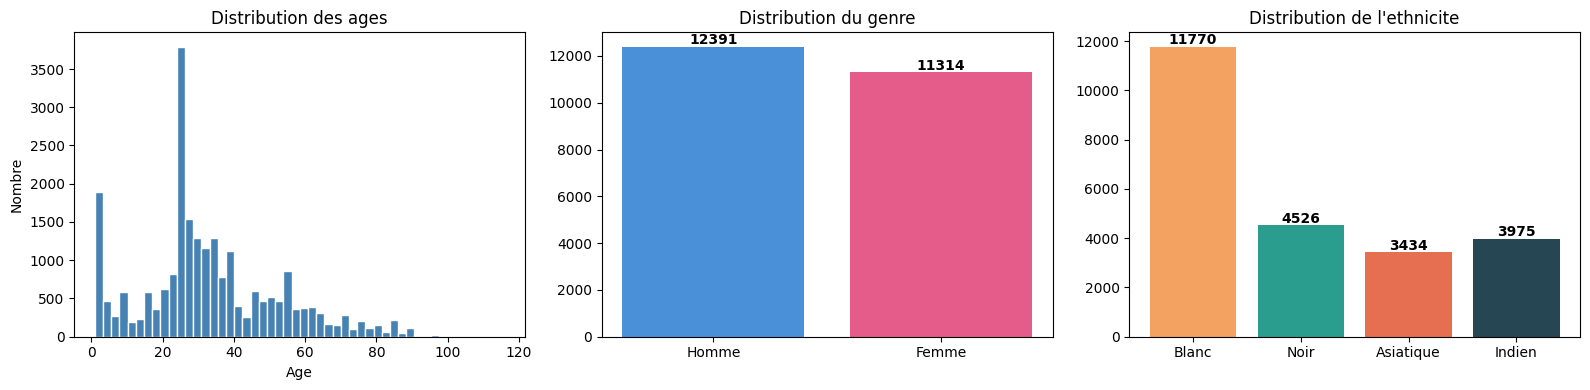

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution des ages
axes[0].hist(ages, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution des ages")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Nombre")

# Distribution du genre
gender_labels = ["Homme", "Femme"]
gender_counts = [int((genders == 0).sum()), int((genders == 1).sum())]
axes[1].bar(gender_labels, gender_counts, color=["#4A90D9", "#E55B8A"])
axes[1].set_title("Distribution du genre")
for i, v in enumerate(gender_counts):
    axes[1].text(i, v + 100, str(v), ha="center", fontweight="bold")

# Distribution de l'ethnicite
eth_labels = ["Blanc", "Noir", "Asiatique", "Indien"]
eth_counts = np.bincount(ethnicities, minlength=4)
axes[2].bar(eth_labels, eth_counts, color=["#F4A261", "#2A9D8F", "#E76F51", "#264653"])
axes[2].set_title("Distribution de l'ethnicite")
for i, v in enumerate(eth_counts):
    axes[2].text(i, v + 100, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dataset_distribution.png", dpi=150)
plt.show()

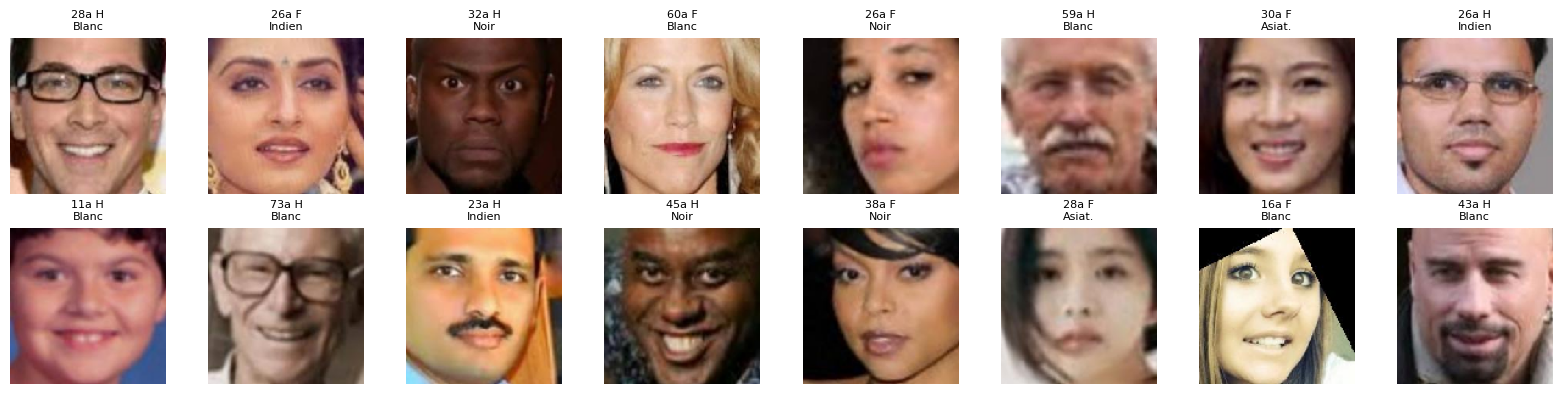

In [6]:
# Echantillon d'images (chargement à la demande)
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
indices = np.random.choice(len(filepaths), 16, replace=False)
gender_map = {0: "H", 1: "F"}
eth_map = {0: "Blanc", 1: "Noir", 2: "Asiat.", 3: "Indien"}

for i, idx in enumerate(indices):
    ax = axes[i // 8][i % 8]
    # Charger uniquement l'image nécessaire
    img = keras.preprocessing.image.load_img(
        str(filepaths[idx]), target_size=(INPUT_SIZE, INPUT_SIZE)
    )
    img_arr = keras.preprocessing.image.img_to_array(img)
    ax.imshow(img_arr.astype(np.uint8))
    ax.set_title(
        f"{int(ages[idx])}a {gender_map[int(genders[idx])]}\n{eth_map[int(ethnicities[idx])]}",
        fontsize=8,
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Split Train / Validation / Test


In [7]:
# Split train / val / test sans charger les pixels
paths = np.array([str(p) for p in filepaths])
idx = np.arange(len(paths))
idx_train, idx_test = train_test_split(idx, test_size=0.15, random_state=42)
idx_train, idx_val = train_test_split(idx_train, test_size=0.15, random_state=42)

train_paths, val_paths, test_paths = (
    paths[idx_train],
    paths[idx_val],
    paths[idx_test],
)

y_age_train, y_age_val, y_age_test = ages[idx_train], ages[idx_val], ages[idx_test]
y_gen_train, y_gen_val, y_gen_test = (
    genders[idx_train],
    genders[idx_val],
    genders[idx_test],
)
y_eth_train, y_eth_val, y_eth_test = (
    ethnicities[idx_train],
    ethnicities[idx_val],
    ethnicities[idx_test],
)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Train: 17126 | Val: 3023 | Test: 3556


## 7. Architecture MoE


In [8]:
class MoEHead(layers.Layer):
    """
    Mixture of Experts head pour une tache.
    Chaque expert est un petit MLP. Le gating network decide
    le poids de chaque expert pour chaque input.
    """

    def __init__(
        self, num_experts, expert_hidden, output_dim, name_prefix="moe", **kwargs
    ):
        super().__init__(**kwargs)
        self.num_experts = num_experts
        self.expert_hidden = expert_hidden
        self.output_dim = output_dim
        self.name_prefix = name_prefix

        # Gating network
        self.gate_dense = layers.Dense(
            64, activation="relu", name=f"{name_prefix}_gate_dense"
        )
        self.gate_out = layers.Dense(
            num_experts, activation="softmax", name=f"{name_prefix}_gate_out"
        )

        # Experts
        self.expert_hiddens = []
        self.expert_dropouts = []
        self.expert_outputs = []
        for i in range(num_experts):
            self.expert_hiddens.append(
                layers.Dense(
                    expert_hidden, activation="relu", name=f"{name_prefix}_exp{i}_h"
                )
            )
            self.expert_dropouts.append(
                layers.Dropout(0.2, name=f"{name_prefix}_exp{i}_drop")
            )
            self.expert_outputs.append(
                layers.Dense(output_dim, name=f"{name_prefix}_exp{i}_out")
            )

    def call(self, features, training=False):
        # Gating: (batch, num_experts)
        gate = self.gate_dense(features)
        gate = self.gate_out(gate)

        # Experts
        expert_outs = []
        for i in range(self.num_experts):
            x = self.expert_hiddens[i](features)
            x = self.expert_dropouts[i](x, training=training)
            x = self.expert_outputs[i](x)
            expert_outs.append(x)

        # Stack: (batch, num_experts, output_dim)
        expert_stack = tf.stack(expert_outs, axis=1)

        # Gate: (batch, num_experts, 1)
        gate_expanded = tf.expand_dims(gate, axis=-1)

        # Weighted sum: (batch, output_dim)
        return tf.reduce_sum(expert_stack * gate_expanded, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "num_experts": self.num_experts,
                "expert_hidden": self.expert_hidden,
                "output_dim": self.output_dim,
                "name_prefix": self.name_prefix,
            }
        )
        return config

In [9]:
def build_moe_model(input_shape=(128, 128, 3), num_experts=3, expert_hidden=128):
    """Construit le modele MoE avec backbone MobileNetV3Small + Rescaling."""

    backbone = MobileNetV3Small(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
        include_preprocessing=False,
    )

    # Freeze TOUT le backbone pour le warmup
    for layer in backbone.layers:
        layer.trainable = False

    # Input -> Rescaling [-1, 1] (requis par MobileNetV3 imagenet)
    inputs = layers.Input(shape=input_shape, name="input_image")
    x = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="rescaling")(inputs)
    x = backbone(x, training=False)

    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="bn_features")(x)
    features = layers.Dropout(0.3, name="drop_features")(x)

    # --- Gender MoE (binary) ---
    gender_moe = MoEHead(num_experts, expert_hidden, 1, name_prefix="gender")
    gender_raw = gender_moe(features)
    gender_output = layers.Activation("sigmoid", name="gender_output")(gender_raw)

    # --- Age MoE (regression) ---
    age_moe = MoEHead(num_experts, expert_hidden, 1, name_prefix="age")
    age_output = layers.Activation("linear", name="age_output")(age_moe(features))

    # --- Ethnicity MoE (4 classes) ---
    eth_moe = MoEHead(num_experts, expert_hidden, 4, name_prefix="ethnicity")
    eth_raw = eth_moe(features)
    eth_output = layers.Activation("softmax", name="ethnicity_output")(eth_raw)

    model = Model(inputs=inputs, outputs=[gender_output, age_output, eth_output])
    return model, backbone


model, backbone = build_moe_model(
    input_shape=(INPUT_SIZE, INPUT_SIZE, 3),
    num_experts=NUM_EXPERTS,
    expert_hidden=EXPERT_HIDDEN,
)

# Verifier le freeze
trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
total = model.count_params()
print(f"Total params: {total:,}")
print(f"Trainable (MoE heads only): {trainable:,}")
print(f"Frozen (backbone): {total - trainable:,}")
model.summary(show_trainable=True)

Total params: 1,719,819
Trainable (MoE heads only): 779,547
Frozen (backbone): 940,272
Model: "model"
_____________________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  Trainable  
 input_image (InputLayer)    [(None, 128, 128, 3)]        0         []                            Y          
                                                                                                             
 rescaling (Rescaling)       (None, 128, 128, 3)          0         ['input_image[0][0]']         Y          
                                                                                                             
 MobilenetV3small (Function  (None, 4, 4, 576)            939120    ['rescaling[0][0]']           Y          
 al)                                                                                                         
                  

In [10]:
# Visualisation de l'architecture
keras.utils.plot_model(
    model,
    to_file=f"{OUTPUT_DIR}/moe_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=100,
)

total_params = model.count_params()
trainable_params = sum(
    tf.keras.backend.count_params(w) for w in model.trainable_weights
)
print(f"\nTotal params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Non-trainable: {total_params - trainable_params:,}")

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.

Total params: 1,719,819
Trainable params: 779,547
Non-trainable: 940,272


## 8. Data augmentation & datasets


Datasets crees avec succes !


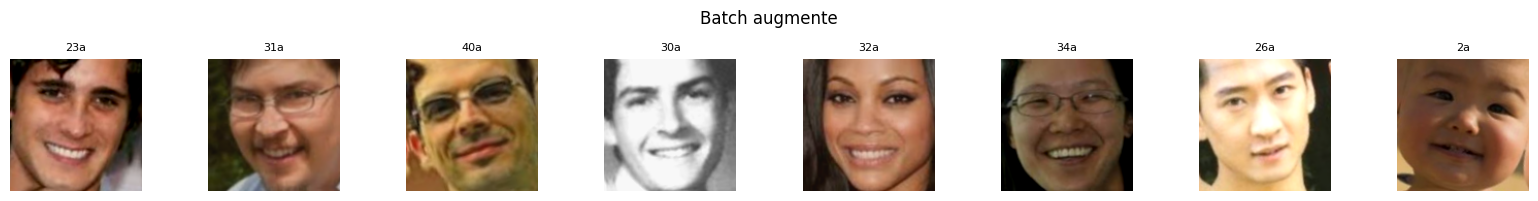

In [11]:
augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomBrightness(0.15),
        layers.RandomContrast(0.15),
    ],
    name="augmentation",
)


def decode_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [INPUT_SIZE, INPUT_SIZE])
    return tf.cast(img, tf.float32)


def make_dataset(paths, y_gen, y_age, y_eth, batch_size, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, y_gen, y_age, y_eth))
    if augment:
        ds = ds.shuffle(buffer_size=min(len(paths), 20000), seed=42)

    def _load(path, gen, age, eth):
        img = decode_image(path)
        return img, {
            "gender_output": tf.cast(gen, tf.float32),
            "age_output": tf.cast(age, tf.float32),
            "ethnicity_output": tf.cast(eth, tf.int32),
        }

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        ds = ds.map(
            lambda x, y: (augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE,
        )

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(
    train_paths, y_gen_train, y_age_train, y_eth_train, BATCH_SIZE, augment=True
)
val_ds = make_dataset(val_paths, y_gen_val, y_age_val, y_eth_val, BATCH_SIZE)
test_ds = make_dataset(test_paths, y_gen_test, y_age_test, y_eth_test, BATCH_SIZE)

print("Datasets crees avec succes !")

# Apercu d'un batch augmente
for batch_x, batch_y in train_ds.take(1):
    fig, axes = plt.subplots(1, 8, figsize=(16, 2))
    for i in range(8):
        axes[i].imshow(batch_x[i].numpy().clip(0, 255).astype(np.uint8))
        axes[i].set_title(f"{int(batch_y['age_output'][i])}a", fontsize=8)
        axes[i].axis("off")
    plt.suptitle("Batch augmente")
    plt.tight_layout()
    plt.show()

## 9. Phase 1 : Warmup (backbone freeze)


In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss={
        "gender_output": "binary_crossentropy",
        "age_output": "mae",
        "ethnicity_output": "sparse_categorical_crossentropy",
    },
    loss_weights={
        "gender_output": 1.0,
        "age_output": 0.1,
        "ethnicity_output": 1.0,
    },
    metrics={
        "gender_output": ["accuracy"],
        "age_output": ["mae"],
        "ethnicity_output": ["accuracy"],
    },
)

callbacks_phase1 = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        min_delta=0.01,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        f"{OUTPUT_DIR}/moe_warmup_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

print(f"Phase 1: Warmup ({WARMUP_EPOCHS} epochs, backbone FREEZE)")

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=callbacks_phase1,
    verbose=1,
)

Phase 1: Warmup (25 epochs, backbone FREEZE)
Epoch 1/25
535/536 [============================>.] - ETA: 0s - loss: 2.6533 - gender_output_loss: 0.4663 - age_output_loss: 11.8099 - ethnicity_output_loss: 1.0059 - gender_output_accuracy: 0.7803 - age_output_mae: 11.8099 - ethnicity_output_accuracy: 0.6046
Epoch 1: val_loss improved from inf to 2.15837, saving model to /home/carld/face-analysis-deep-learning/artifacts/moe_mobilenetv3/moe_warmup_best.keras
536/536 [==============================] - 40s 65ms/step - loss: 2.6535 - gender_output_loss: 0.4664 - age_output_loss: 11.8096 - ethnicity_output_loss: 1.0061 - gender_output_accuracy: 0.7802 - age_output_mae: 11.8096 - ethnicity_output_accuracy: 0.6046 - val_loss: 2.1584 - val_gender_output_loss: 0.3536 - val_age_output_loss: 9.8041 - val_ethnicity_output_loss: 0.8244 - val_gender_output_accuracy: 0.8369 - val_age_output_mae: 9.8041 - val_ethnicity_output_accuracy: 0.6685 - lr: 0.0010
Epoch 2/25
535/536 [============================>.]

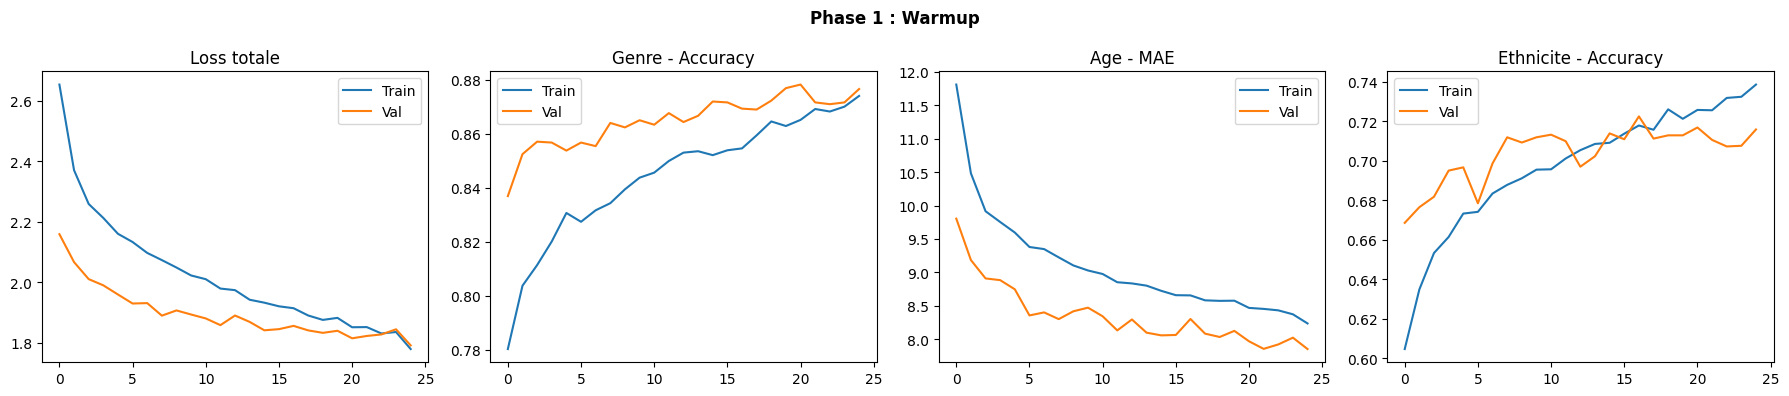

In [15]:
# Courbes Phase 1
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(history1.history["loss"], label="Train")
axes[0].plot(history1.history["val_loss"], label="Val")
axes[0].set_title("Loss totale")
axes[0].legend()

axes[1].plot(history1.history["gender_output_accuracy"], label="Train")
axes[1].plot(history1.history["val_gender_output_accuracy"], label="Val")
axes[1].set_title("Genre - Accuracy")
axes[1].legend()

axes[2].plot(history1.history["age_output_mae"], label="Train")
axes[2].plot(history1.history["val_age_output_mae"], label="Val")
axes[2].set_title("Age - MAE")
axes[2].legend()

axes[3].plot(history1.history["ethnicity_output_accuracy"], label="Train")
axes[3].plot(history1.history["val_ethnicity_output_accuracy"], label="Val")
axes[3].set_title("Ethnicite - Accuracy")
axes[3].legend()

plt.suptitle("Phase 1 : Warmup", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/phase1_curves.png", dpi=150)
plt.show()

## 10. Phase 2 : Degel progressif (unfreezing par blocs)

Le fine-tuning se fait en **3 etapes** pour eviter le collapse :

1. Degel des 30 dernieres couches du backbone
2. Degel des 60 dernieres couches
3. Degel complet

Chaque etape utilise un LR tres faible (2e-5) avec monitoring strict du val_loss.


In [16]:
def progressive_unfreeze(backbone, model, num_layers_to_unfreeze):
    """Degel progressif : unfreeze les N dernieres couches du backbone."""
    total = len(backbone.layers)
    for layer in backbone.layers:
        layer.trainable = False
    for layer in backbone.layers[max(0, total - num_layers_to_unfreeze) :]:
        layer.trainable = True
    # GELER toutes les BatchNormalization pour eviter le catastrophic forgetting
    for layer in backbone.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
    # Les MoE heads restent toujours trainable
    trainable_count = sum(
        tf.keras.backend.count_params(w) for w in model.trainable_weights
    )
    return trainable_count


def finetune_phase(
    model,
    backbone,
    unfreeze_layers,
    phase_name,
    lr,
    epochs_start,
    epochs_end,
    patience=5,
):
    """Execute une phase de fine-tuning avec degel progressif."""
    trainable_count = progressive_unfreeze(backbone, model, unfreeze_layers)
    print(f"\n{'='*60}")
    print(f"{phase_name}: Unfreeze {unfreeze_layers} dernieres couches")
    print(f"  Trainable params: {trainable_count:,}")
    print(f"  LR: {lr}, Epochs: {epochs_start}->{epochs_end}")
    print(f"{'='*60}")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss={
            "gender_output": "binary_crossentropy",
            "age_output": "mae",
            "ethnicity_output": "sparse_categorical_crossentropy",
        },
        loss_weights={
            "gender_output": 1.0,
            "age_output": 0.1,
            "ethnicity_output": 1.0,
        },
        metrics={
            "gender_output": ["accuracy"],
            "age_output": ["mae"],
            "ethnicity_output": ["accuracy"],
        },
    )

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            min_delta=0.005,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            f"{OUTPUT_DIR}/moe_best.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs_end,
        initial_epoch=epochs_start,
        callbacks=callbacks,
        verbose=1,
    )
    return history


# Phase 2a: Degel des 30 dernieres couches
warmup_end = len(history1.epoch)
phase2a_end = warmup_end + 15

history2a = finetune_phase(
    model,
    backbone,
    unfreeze_layers=30,
    phase_name="Phase 2a",
    lr=FINETUNE_LR,
    epochs_start=warmup_end,
    epochs_end=phase2a_end,
    patience=5,
)

# Phase 2b: Degel des 60 dernieres couches
phase2b_start = warmup_end + len(history2a.epoch)
phase2b_end = phase2b_start + 15

history2b = finetune_phase(
    model,
    backbone,
    unfreeze_layers=60,
    phase_name="Phase 2b",
    lr=FINETUNE_LR * 0.5,  # 1e-5
    epochs_start=phase2b_start,
    epochs_end=phase2b_end,
    patience=5,
)

# Phase 2c: Degel complet
phase2c_start = phase2b_start + len(history2b.epoch)
phase2c_end = phase2c_start + 20

history2c = finetune_phase(
    model,
    backbone,
    unfreeze_layers=len(backbone.layers),  # tout
    phase_name="Phase 2c (FULL)",
    lr=FINETUNE_LR * 0.25,  # 5e-6
    epochs_start=phase2c_start,
    epochs_end=phase2c_end,
    patience=7,
)

# Combiner les historiques pour le plot
history2 = type("History", (), {"history": {}})()
for key in history2a.history:
    history2.history[key] = (
        history2a.history[key]
        + history2b.history.get(key, [])
        + history2c.history.get(key, [])
    )

print(f"\nFine-tuning termine !")
print(f"  Total epochs: {phase2c_start + len(history2c.epoch)}")
final_trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"  Trainable params final: {final_trainable:,}")


Phase 2a: Unfreeze 30 dernieres couches
  Trainable params: 1,126,443
  LR: 2e-05, Epochs: 25->40
Epoch 26/40
208/536 [==========>...................] - ETA: 19s - loss: 1.7159 - gender_output_loss: 0.2757 - age_output_loss: 8.2773 - ethnicity_output_loss: 0.6125 - gender_output_accuracy: 0.8827 - age_output_mae: 8.2773 - ethnicity_output_accuracy: 0.7559

KeyboardInterrupt: 

NameError: name 'history2' is not defined

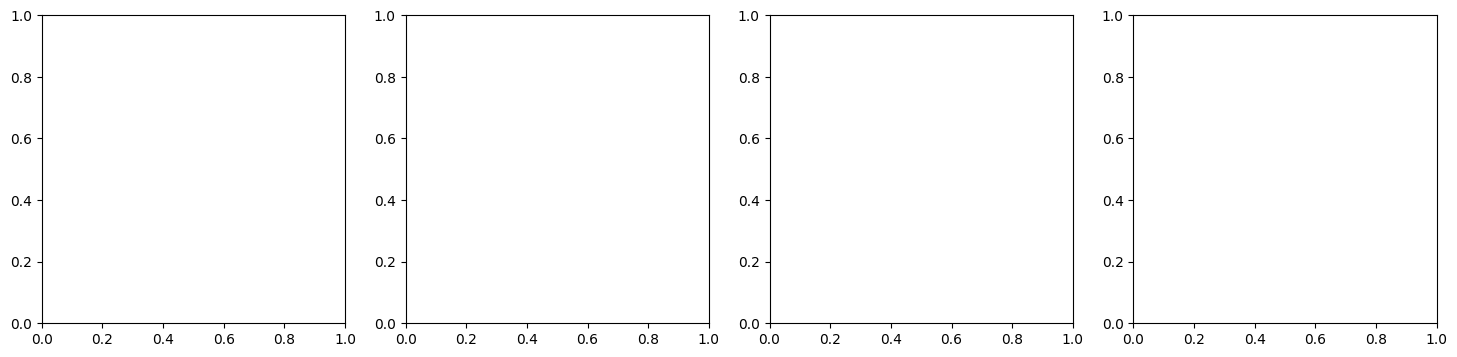

In [17]:
# Courbes Phase 2
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(history2.history["loss"], label="Train")
axes[0].plot(history2.history["val_loss"], label="Val")
axes[0].set_title("Loss totale")
axes[0].legend()

axes[1].plot(history2.history["gender_output_accuracy"], label="Train")
axes[1].plot(history2.history["val_gender_output_accuracy"], label="Val")
axes[1].set_title("Genre - Accuracy")
axes[1].legend()

axes[2].plot(history2.history["age_output_mae"], label="Train")
axes[2].plot(history2.history["val_age_output_mae"], label="Val")
axes[2].set_title("Age - MAE")
axes[2].legend()

axes[3].plot(history2.history["ethnicity_output_accuracy"], label="Train")
axes[3].plot(history2.history["val_ethnicity_output_accuracy"], label="Val")
axes[3].set_title("Ethnicite - Accuracy")
axes[3].legend()

plt.suptitle("Phase 2 : Fine-tuning", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/phase2_curves.png", dpi=150)
plt.show()

## 11. Evaluation sur le test set


In [18]:
# Charger le meilleur checkpoint (warmup ou fine-tuning)
import os

warmup_path = f"{OUTPUT_DIR}/moe_warmup_best.keras"
best_path = f"{OUTPUT_DIR}/moe_best.keras"

# Comparer les val_loss pour choisir le meilleur
warmup_val = model.evaluate(val_ds, verbose=0)[0]  # loss actuelle

# Recharger le warmup pour comparer
model_warmup = keras.models.load_model(warmup_path, custom_objects={"MoEHead": MoEHead})
warmup_val_loss = model_warmup.evaluate(val_ds, verbose=0)[0]

current_val_loss = model.evaluate(val_ds, verbose=0)[0]

if warmup_val_loss < current_val_loss:
    print(
        f"Le warmup est meilleur (val_loss: {warmup_val_loss:.4f} < {current_val_loss:.4f})"
    )
    model = model_warmup
else:
    print(
        f"Le fine-tuning est meilleur (val_loss: {current_val_loss:.4f} < {warmup_val_loss:.4f})"
    )

del model_warmup

print("=" * 50)
print("EVALUATION SUR LE TEST SET")
print("=" * 50)

results = model.evaluate(test_ds, verbose=1)

print(f"\nResultats:")
for name, value in zip(model.metrics_names, results):
    print(f"  {name}: {value:.4f}")

Le fine-tuning est meilleur (val_loss: 1.7340 < 1.7904)
EVALUATION SUR LE TEST SET
112/112 [==============================] - 5s 45ms/step - loss: 1.8300 - gender_output_loss: 0.3375 - age_output_loss: 7.6900 - ethnicity_output_loss: 0.7235 - gender_output_accuracy: 0.8535 - age_output_mae: 7.6900 - ethnicity_output_accuracy: 0.7286

Resultats:
  loss: 1.8300
  gender_output_loss: 0.3375
  age_output_loss: 7.6900
  ethnicity_output_loss: 0.7235
  gender_output_accuracy: 0.8535
  age_output_mae: 7.6900
  ethnicity_output_accuracy: 0.7286


In [19]:
# Predictions detaillees
from sklearn.metrics import classification_report, confusion_matrix

pred_gender, pred_age, pred_eth = model.predict(test_ds, verbose=1)

# Genre
pred_gender_class = (pred_gender.flatten() > 0.5).astype(int)
print("\n=== GENRE ===")
print(
    classification_report(
        y_gen_test, pred_gender_class, target_names=["Homme", "Femme"]
    )
)

# Age
pred_age_int = pred_age.flatten().astype(int).clip(0, 116)
age_mae = np.abs(pred_age_int - y_age_test).mean()
print(f"\n=== AGE ===")
print(f"MAE: {age_mae:.2f} ans")

# Ethnicite
pred_eth_class = pred_eth.argmax(axis=1)
eth_names = ["Blanc", "Noir", "Asiatique", "Indien"]
print("\n=== ETHNICITE ===")
print(classification_report(y_eth_test, pred_eth_class, target_names=eth_names))

112/112 [==============================] - 7s 56ms/step

=== GENRE ===
              precision    recall  f1-score   support

       Homme       0.84      0.89      0.86      1829
       Femme       0.88      0.81      0.84      1727

    accuracy                           0.85      3556
   macro avg       0.86      0.85      0.85      3556
weighted avg       0.85      0.85      0.85      3556


=== AGE ===
MAE: 7.78 ans

=== ETHNICITE ===
              precision    recall  f1-score   support

       Blanc       0.74      0.87      0.80      1747
        Noir       0.77      0.71      0.74       659
   Asiatique       0.68      0.51      0.58       525
      Indien       0.66      0.52      0.58       625

    accuracy                           0.73      3556
   macro avg       0.71      0.66      0.68      3556
weighted avg       0.72      0.73      0.72      3556



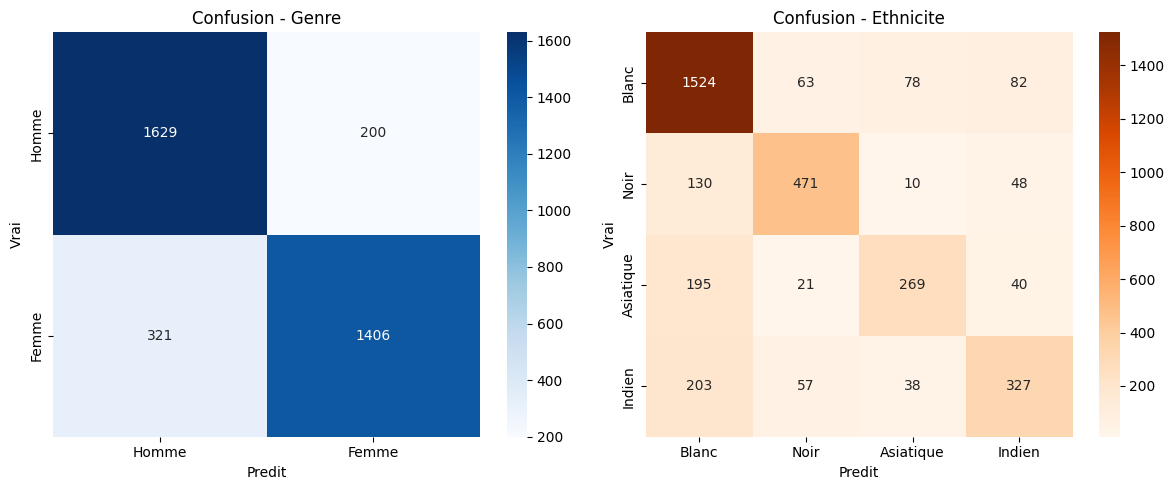

In [20]:
# Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Genre
cm_gender = confusion_matrix(y_gen_test, pred_gender_class)
sns.heatmap(
    cm_gender,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Homme", "Femme"],
    yticklabels=["Homme", "Femme"],
    ax=axes[0],
)
axes[0].set_title("Confusion - Genre")
axes[0].set_ylabel("Vrai")
axes[0].set_xlabel("Predit")

# Ethnicite
cm_eth = confusion_matrix(y_eth_test, pred_eth_class)
sns.heatmap(
    cm_eth,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=eth_names,
    yticklabels=eth_names,
    ax=axes[1],
)
axes[1].set_title("Confusion - Ethnicite")
axes[1].set_ylabel("Vrai")
axes[1].set_xlabel("Predit")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrices.png", dpi=150)
plt.show()

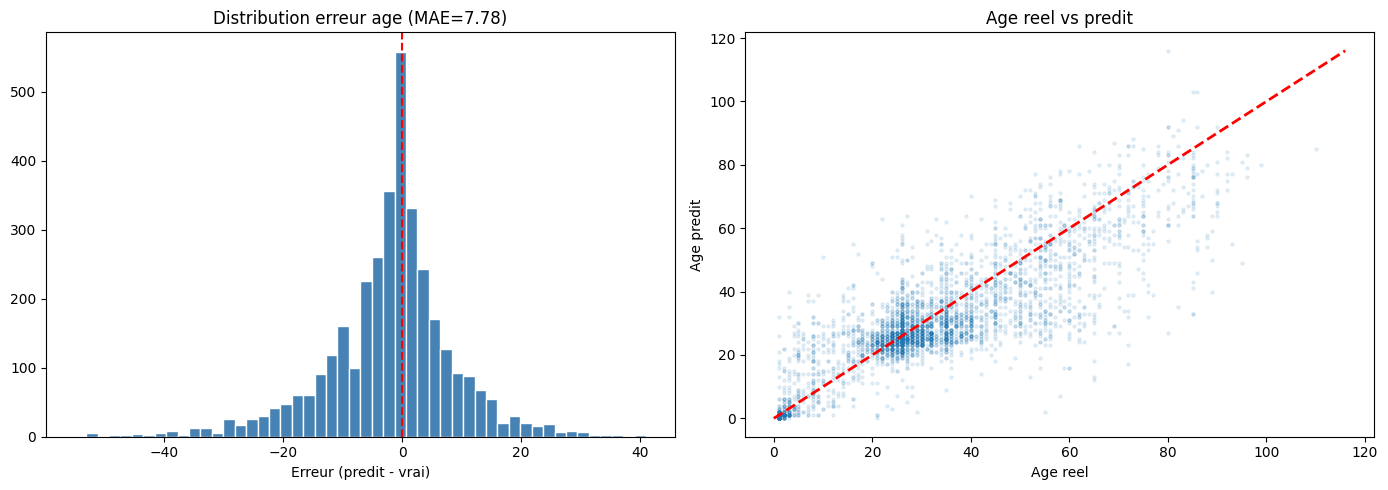

In [21]:
# Distribution erreur age
age_errors = pred_age_int - y_age_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(age_errors, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(x=0, color="red", linestyle="--")
axes[0].set_title(f"Distribution erreur age (MAE={age_mae:.2f})")
axes[0].set_xlabel("Erreur (predit - vrai)")

axes[1].scatter(y_age_test, pred_age_int, alpha=0.1, s=5)
axes[1].plot([0, 116], [0, 116], "r--", linewidth=2)
axes[1].set_xlabel("Age reel")
axes[1].set_ylabel("Age predit")
axes[1].set_title("Age reel vs predit")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/age_analysis.png", dpi=150)
plt.show()

## 12. Analyse des Gating Networks

Visualisons quels experts sont actives pour differents types d'inputs.


In [22]:
# Extraire les sorties des gating networks
gate_layer_names = [
    "gender_gate_out",
    "age_gate_out",
    "ethnicity_gate_out",
]

# Trouver les couches
gate_outputs = []
for name in gate_layer_names:
    found = False
    for layer in model.layers:
        if hasattr(layer, "gate_out"):
            found = True
            break
    if not found:
        # Chercher dans les sous-couches
        for layer in model.layers:
            if name in layer.name:
                gate_outputs.append(layer.output)
                break

# Echantillon leger pour analyse (pas de chargement massif)
sample_size = min(200, len(test_paths))
sample_ages = y_age_test[:sample_size]
sample_genders = y_gen_test[:sample_size]
sample_ethnicities = y_eth_test[:sample_size]

print(f"Gating analysis sur {sample_size} echantillons du test set")
print(f"  Ages: {sample_ages.min():.0f}-{sample_ages.max():.0f}")
print(
    f"  Genres: {int((sample_genders == 0).sum())}H / {int((sample_genders == 1).sum())}F"
)
print(f"  Ethnicites: {np.bincount(sample_ethnicities.astype(int), minlength=4)}")

Gating analysis sur 200 echantillons du test set
  Ages: 1-95
  Genres: 106H / 94F
  Ethnicites: [103  29  31  37]


## 13. Sauvegarde du modele Keras


In [23]:
keras_path = f"{OUTPUT_DIR}/moe_mobilenetv3.keras"
model.save(keras_path)
print(f"Modele Keras sauvegarde: {keras_path}")

# Taille du fichier
size_mb = os.path.getsize(keras_path) / (1024 * 1024)
print(f"Taille: {size_mb:.1f} MB")

Modele Keras sauvegarde: /home/carld/face-analysis-deep-learning/artifacts/moe_mobilenetv3/moe_mobilenetv3.keras
Taille: 15.9 MB


## 14. Conversion TFLite


In [24]:
# Conversion
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float32]

tflite_model = converter.convert()

tflite_path = f"{OUTPUT_DIR}/moe_mobilenetv3.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

size_mb = len(tflite_model) / (1024 * 1024)
print(f"Modele TFLite sauvegarde: {tflite_path}")
print(f"Taille: {size_mb:.1f} MB")

INFO:tensorflow:Assets written to: /tmp/tmpznj4rx77/assets


INFO:tensorflow:Assets written to: /tmp/tmpznj4rx77/assets


Modele TFLite sauvegarde: /home/carld/face-analysis-deep-learning/artifacts/moe_mobilenetv3/moe_mobilenetv3.tflite
Taille: 6.6 MB


2026-03-24 23:58:39.508905: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-24 23:58:39.508949: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-24 23:58:39.509399: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpznj4rx77
2026-03-24 23:58:39.525586: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-24 23:58:39.525623: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpznj4rx77
2026-03-24 23:58:39.562347: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-03-24 23:58:39.580669: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-03-24 23:58:39.962850: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpznj4rx77
2026-03

In [25]:
# Verification du modele TFLite
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

print("Inputs TFLite:")
for inp in interpreter.get_input_details():
    print(
        f"  [{inp['index']}] {inp['name']}: shape={inp['shape']}, dtype={inp['dtype']}"
    )

print("\nOutputs TFLite:")
for out in interpreter.get_output_details():
    print(
        f"  [{out['index']}] {out['name']}: shape={out['shape']}, dtype={out['dtype']}"
    )

Inputs TFLite:
  [0] serving_default_input_image:0: shape=[  1 128 128   3], dtype=<class 'numpy.float32'>

Outputs TFLite:
  [297] StatefulPartitionedCall:0: shape=[1 1], dtype=<class 'numpy.float32'>
  [284] StatefulPartitionedCall:2: shape=[1 1], dtype=<class 'numpy.float32'>
  [311] StatefulPartitionedCall:1: shape=[1 4], dtype=<class 'numpy.float32'>


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Test inference TFLite:
  Gender: 0.704 (Femme)
  Age: 4.6 (vrai: 4)
  Ethnicity: Noir (vrai: Indien)


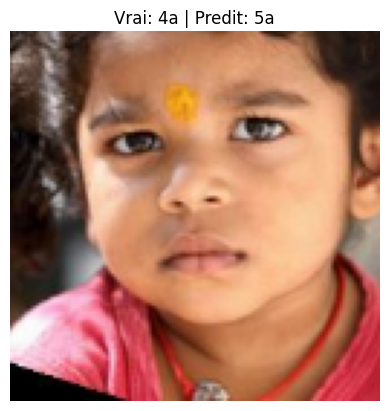

In [26]:
# Test rapide d'inference TFLite
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Prendre une image de test (chargement à la demande)
first_test_path = test_paths[0]
test_img = decode_image(tf.constant(first_test_path))
test_img = tf.expand_dims(test_img, axis=0)  # batch 1

tester = tf.cast(test_img, tf.float32)
interpreter.set_tensor(input_details[0]["index"], tester)
interpreter.invoke()

# ATTENTION: TFLite réordonne les sorties !
# output[0] = age (suffix :1), output[1] = gender (suffix :0), output[2] = ethnicity (suffix :2)
age_out = interpreter.get_tensor(output_details[0]["index"])
gender_out = interpreter.get_tensor(output_details[1]["index"])
eth_out = interpreter.get_tensor(output_details[2]["index"])

print(f"Test inference TFLite:")
print(
    f"  Gender: {gender_out[0][0]:.3f} ({'Femme' if gender_out[0][0] > 0.5 else 'Homme'})"
)
print(f"  Age: {age_out[0][0]:.1f} (vrai: {int(y_age_test[0])})")
print(
    f"  Ethnicity: {eth_names[eth_out[0].argmax()]} (vrai: {eth_names[int(y_eth_test[0])]})"
)

# Afficher l'image
plt.imshow(test_img[0].numpy().astype(np.uint8))
plt.title(f"Vrai: {int(y_age_test[0])}a | Predit: {age_out[0][0]:.0f}a")
plt.axis("off")
plt.show()

## 15. Copier le modele dans l'app Android

Execute cette cellule pour copier automatiquement le `.tflite` dans les assets de l'app.


In [29]:
import shutil, os

# Chemin des assets Android depuis config.py
assets_dir = str(ANDROID_ASSETS_DIR)
dest_path = os.path.join(assets_dir, "moe_mobilenetv3.tflite")

# S'assure que le dossier existe
os.makedirs(assets_dir, exist_ok=True)

if not os.path.exists(tflite_path):
    print(f"Fichier TFLite introuvable: {tflite_path}")
else:
    shutil.copy2(tflite_path, dest_path)
    size_mb = os.path.getsize(dest_path) / (1024 * 1024)
    print(f"Modele copie vers: {dest_path}")
    print(f"Taille: {size_mb:.1f} MB")
    print("\nTu peux maintenant rebuild l'APK !")

Modele copie vers: /home/carld/face-analysis-deep-learning/FacePredictor/app/src/main/assets/moe_mobilenetv3.tflite
Taille: 6.6 MB

Tu peux maintenant rebuild l'APK !
